<a href="https://colab.research.google.com/github/engineerchacon/Maestria-en-Inteligencia-Artificial-y-Analitica-de-Datos-Colab-Files/blob/main/Semana_14_ModelSelection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualización de Overfitting y Underfitting con Árboles de Decisión
Este notebook muestra cómo un árbol de decisión puede sufrir underfitting o overfitting dependiendo del valor del hiperparámetro `max_depth`.

**Objetivo:** Visualizar y analizar los errores en entrenamiento y prueba en función de la complejidad del modelo.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Entrenar modelos con diferentes profundidades y evaluar su rendimiento

In [ ]:
train_accuracies = []
test_accuracies = []
depths = range(1, 21)

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, clf.predict(X_test)))

## Graficar errores en entrenamiento y prueba

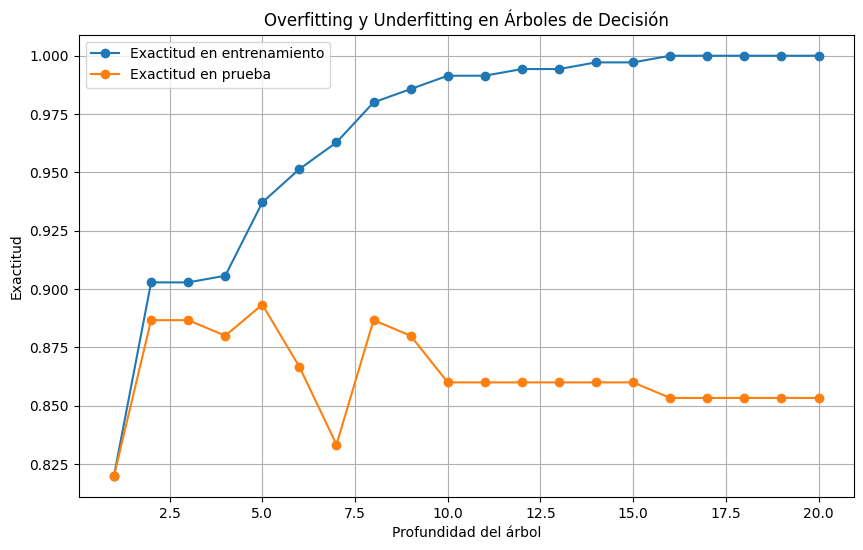

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(depths, train_accuracies, label='Exactitud en entrenamiento', marker='o')
plt.plot(depths, test_accuracies, label='Exactitud en prueba', marker='o')
plt.xlabel('Profundidad del árbol')
plt.ylabel('Exactitud')
plt.title('Overfitting y Underfitting en Árboles de Decisión')
plt.legend()
plt.grid(True)
plt.show()

### Análisis:
- **Underfitting**: Exactitud baja tanto en entrenamiento como en prueba (profundidad muy baja).
- **Ajuste ideal**: Exactitud alta en ambos conjuntos.
- **Overfitting**: Exactitud muy alta en entrenamiento, pero disminuye en prueba conforme se incrementa la profundidad.

# ¿Qué es GridSearch?

GridSearchCV (del inglés grid search cross-validation) es una técnica de búsqueda exhaustiva utilizada para encontrar la mejor combinación de hiperparámetros para un modelo de aprendizaje automático. Recorre todas las combinaciones posibles de hiperparámetros en una malla (grid) definida por el usuario, y evalúa cada combinación mediante validación cruzada para seleccionar la que tenga el mejor desempeño según una métrica específica (ej. accuracy, f1, etc.).

---
## ¿Por qué es útil?

En muchos modelos, los hiperparámetros controlan la capacidad, flexibilidad y regularización. Ajustarlos adecuadamente mejora el rendimiento de generalización del modelo. GridSearchCV facilita:

- Comparar muchas combinaciones de forma sistemática.

- Validar el rendimiento de cada configuración con técnicas como Stratified K-Fold.

- Elegir la mejor sin usar directamente el conjunto de prueba.



In [ ]:
#Árbol de Decisión con GridSearchCV y StratifiedKFold

from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 1. Cargar datos
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2. Definir modelo base
clf = DecisionTreeClassifier(random_state=42)

# 3. Definir espacio de búsqueda
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# 4. Configurar validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Configurar GridSearchCV
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1)

# 6. Ajustar modelo
grid_search.fit(X_train, y_train)

# 7. Resultados
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print("Exactitud en test:", accuracy_score(y_test, grid_search.predict(X_test)))


Mejores hiperparámetros encontrados: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Exactitud en test: 0.9629629629629629


## Ejemplo con un conjunto de datos pequeño

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Cargar el dataset
X, y = load_iris(return_X_y=True)

# 2. Definir el modelo base
clf = DecisionTreeClassifier(random_state=42)

# 3. Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 4, 6]
}

# 4. Leave-One-Out CV
loo = LeaveOneOut()

# 5. Configurar GridSearchCV con LOOCV
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=loo, scoring='accuracy', n_jobs=-1)

# 6. Ajustar el modelo
grid_search.fit(X, y)

# 7. Resultados
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print("Mejor exactitud promedio (LOOCV):", grid_search.best_score_)

Mejores hiperparámetros encontrados: {'max_depth': 2, 'min_samples_split': 2}
Mejor exactitud promedio (LOOCV): 0.9533333333333334


## Conjunto de Datos de Tamaño Mediano

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Cargar el dataset
X, y = load_iris(return_X_y=True)

# 2. Definir el modelo base
clf = DecisionTreeClassifier(random_state=42)

# 3. Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 4, 6]
}

# 4. Stratified
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Configurar GridSearchCV con Strafified
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1)

# 6. Ajustar el modelo
grid_search.fit(X, y)

# 7. Resultados
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print("Mejor exactitud promedio (Stratified):", grid_search.best_score_)



Mejores hiperparámetros encontrados: {'max_depth': 4, 'min_samples_split': 6}
Mejor exactitud promedio (Stratified): 0.9666666666666668


#RandomizedSearchCV

RandomizedSearchCV es una técnica de optimización de hiperparámetros que pertenece a la familia de métodos de búsqueda basados en muestreo aleatorio. Forma parte de Scikit-Learn y se utiliza para encontrar una buena combinación de hiperparámetros para un modelo sin necesidad de evaluar exhaustivamente todas las opciones posibles (como hace GridSearchCV).

En lugar de probar todas las combinaciones posibles (como hace GridSearchCV), RandomizedSearchCV:

- Recibe un espacio de búsqueda de hiperparámetros (rangos o distribuciones).

- Elige aleatoriamente n_iter combinaciones de ese espacio.

- Evalúa cada combinación usando validación cruzada (cv).

- Guarda el modelo que obtiene mejor puntuación.

##Ventajas

| Ventaja                         | Explicación                                                                 |
|----------------------------------|-----------------------------------------------------------------------------|
| Más eficiente                    | No prueba todo, solo una muestra aleatoria.                                |
| Escalable a espacios grandes     | Ideal cuando tienes muchos hiperparámetros o valores continuos.           |
| Flexible                         | Puedes usar distribuciones (`randint`, `uniform`, `loguniform`, etc.)     |
| Reproducible                     | Se puede fijar `random_state` para repetir los experimentos.              |


##Desventajas
| Desventaja                       | Explicación                                                                 |
|----------------------------------|-----------------------------------------------------------------------------|
| Puede omitir la mejor combinación | Como es aleatorio, no garantiza encontrar la óptima si `n_iter` es bajo.  |
| Resultados pueden variar         | Si no se fija `random_state`, los resultados cambian en cada ejecución.    |


In [ ]:
#Árbol de Decisión con RandomizedSearchCV y StratifiedKFold
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from scipy.stats import randint

# 1. Cargar datos
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2. Definir modelo base
clf = DecisionTreeClassifier(random_state=42)

# 3. Definir espacio de búsqueda
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': randint(1, 20),
    'min_samples_split': randint(2, 11)
}

# 4. Configurar validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Configurar búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=10,              # Número de combinaciones aleatorias a probar
    cv=cv,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# 6. Ajustar el modelo
random_search.fit(X_train, y_train)

# 7. Resultados
print("Mejores hiperparámetros encontrados:", random_search.best_params_)
print("Precisión en test:", accuracy_score(y_test, random_search.predict(X_test)))


Mejores hiperparámetros encontrados: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 4}
Precisión en test: 0.9629629629629629


## Randomized Search en Datos Medianos

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Cargar el dataset
X, y = load_iris(return_X_y=True)

# 2. Definir el modelo base
clf = DecisionTreeClassifier(random_state=42)

# 3. Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 4, 6]
}

# 4. Stratified
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Configurar búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=10,              # Número de combinaciones aleatorias a probar
    cv=cv,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# 6. Ajustar el modelo
random_search.fit(X_train, y_train)

# 7. Resultados
print("Mejores hiperparámetros encontrados:", random_search.best_params_)
print("Mejor exactitud promedio (Stratified):", random_search.best_score_)


Mejores hiperparámetros encontrados: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 4}
Mejor exactitud promedio (Stratified): 0.8863333333333333
